# Magnetic Field Line Curvature vs Electron Larmor Radius Analysis

This notebook analyzes the ratio of the radius of curvature of magnetic field lines (Rc) to the Larmor radius of electrons (RL) for various energies and magnetic field models. This ratio is important for understanding particle motion in magnetospheric physics:

- **Rc/RL >> 1**: Adiabatic motion (guiding center approximation valid)
- **Rc/RL ~ 1**: Non-adiabatic effects become important
- **Rc/RL < 1**: Chaotic motion, particle demagnetization

## Key Formulas

1. **Radius of curvature**: $R_c = 1/\kappa$ where $\kappa$ is the field line curvature

2. **Larmor radius**: $R_L = \frac{m v_\perp}{|q| B} = \frac{p_\perp}{|q| B}$

   For relativistic electrons: $R_L = \frac{\gamma m_e v_\perp}{e B}$

3. **Energy relations**:
   - Total energy: $E = \gamma m_e c^2$
   - Kinetic energy: $E_k = (\gamma - 1) m_e c^2$
   - For given pitch angle $\alpha$: $v_\perp = v \sin\alpha$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

# Import geopack
import geopack
from geopack import (
    t89_vectorized, t96_vectorized, t01_vectorized, t04_vectorized,
    field_line_curvature_vectorized
)

# Set up plotting
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# Physical constants
c = 2.99792458e8  # Speed of light (m/s)
me = 9.10938356e-31  # Electron mass (kg)
e = 1.602176634e-19  # Elementary charge (C)
me_c2_keV = 511.0  # Electron rest energy (keV)
Re = 6.371e6  # Earth radius (m)

print("Physical Constants:")
print(f"Electron rest energy: {me_c2_keV} keV")
print(f"Earth radius: {Re/1e6:.3f} Mm")

Load IGRF coefficients ...
Physical Constants:
Electron rest energy: 511.0 keV
Earth radius: 6.371 Mm


In [2]:
# Initialize geopack
ut = 1600000000  # Unix timestamp
ps = geopack.recalc(ut)

# Model parameters
kp = 3  # Moderate activity for T89
parmod_t96 = [2.0, -30.0, 0.5, -3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  # Moderate storm
parmod_t01 = parmod_t96 + [0.5, 0.5]  # Add G1, G2
parmod_t04 = parmod_t96 + [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]  # Add W1-W6

print(f"Dipole tilt: {np.degrees(ps):.2f}°")
print(f"\nModel parameters:")
print(f"T89: Kp = {kp}")
print(f"T96/T01/T04: Pdyn = {parmod_t96[0]} nPa, Dst = {parmod_t96[1]} nT")
print(f"             ByIMF = {parmod_t96[2]} nT, BzIMF = {parmod_t96[3]} nT")

Dipole tilt: 7.42°

Model parameters:
T89: Kp = 3
T96/T01/T04: Pdyn = 2.0 nPa, Dst = -30.0 nT
             ByIMF = 0.5 nT, BzIMF = -3.0 nT


## Helper Functions for Larmor Radius Calculation

In [3]:
def calculate_larmor_radius(energy_keV, B_nT, pitch_angle_deg=90):
    """
    Calculate the Larmor radius for an electron.
    
    Parameters
    ----------
    energy_keV : float or array
        Kinetic energy in keV
    B_nT : float or array
        Magnetic field strength in nT
    pitch_angle_deg : float
        Pitch angle in degrees (default 90° for maximum Larmor radius)
        
    Returns
    -------
    RL_m : float or array
        Larmor radius in meters
    """
    # Convert to SI units
    E_k = energy_keV * 1000 * e  # Convert keV to Joules
    B = B_nT * 1e-9  # Convert nT to Tesla
    
    # Calculate gamma factor
    gamma = 1 + E_k / (me * c**2)
    
    # Calculate velocity
    beta = np.sqrt(1 - 1/gamma**2)
    v = beta * c
    
    # Perpendicular velocity component
    alpha = np.radians(pitch_angle_deg)
    v_perp = v * np.sin(alpha)
    
    # Larmor radius
    RL = gamma * me * v_perp / (e * B)
    
    return RL


def calculate_curvature_radius(model_func, parmod, ps, x, y, z):
    """
    Calculate radius of curvature and magnetic field strength.
    
    Returns
    -------
    Rc : float or array
        Radius of curvature in Re
    B : float or array
        Magnetic field strength in nT
    """
    # Get curvature
    kappa = field_line_curvature_vectorized(model_func, parmod, ps, x, y, z)
    
    # Radius of curvature (handle zero curvature)
    Rc = np.where(kappa > 1e-10, 1.0 / kappa, 1e10)
    
    # Get magnetic field strength
    bx, by, bz = model_func(parmod, ps, x, y, z)
    B = np.sqrt(bx**2 + by**2 + bz**2)
    
    return Rc, B


# Test the functions
test_energy = 100  # keV
test_B = 1000  # nT
test_RL = calculate_larmor_radius(test_energy, test_B)
print(f"Test: {test_energy} keV electron in {test_B} nT field")
print(f"Larmor radius: {test_RL:.2f} m = {test_RL/Re:.6f} Re")

# Calculate gamma and velocity for reference
E_k = test_energy * 1000 * e
gamma = 1 + E_k / (me * c**2)
beta = np.sqrt(1 - 1/gamma**2)
print(f"γ = {gamma:.4f}, β = {beta:.4f}, v = {beta*c/1e6:.1f} Mm/s")

Test: 100 keV electron in 1000 nT field
Larmor radius: 1117.31 m = 0.000175 Re
γ = 1.1957, β = 0.5482, v = 164.4 Mm/s


## Analysis 1: Rc/RL Ratio Along Field Lines

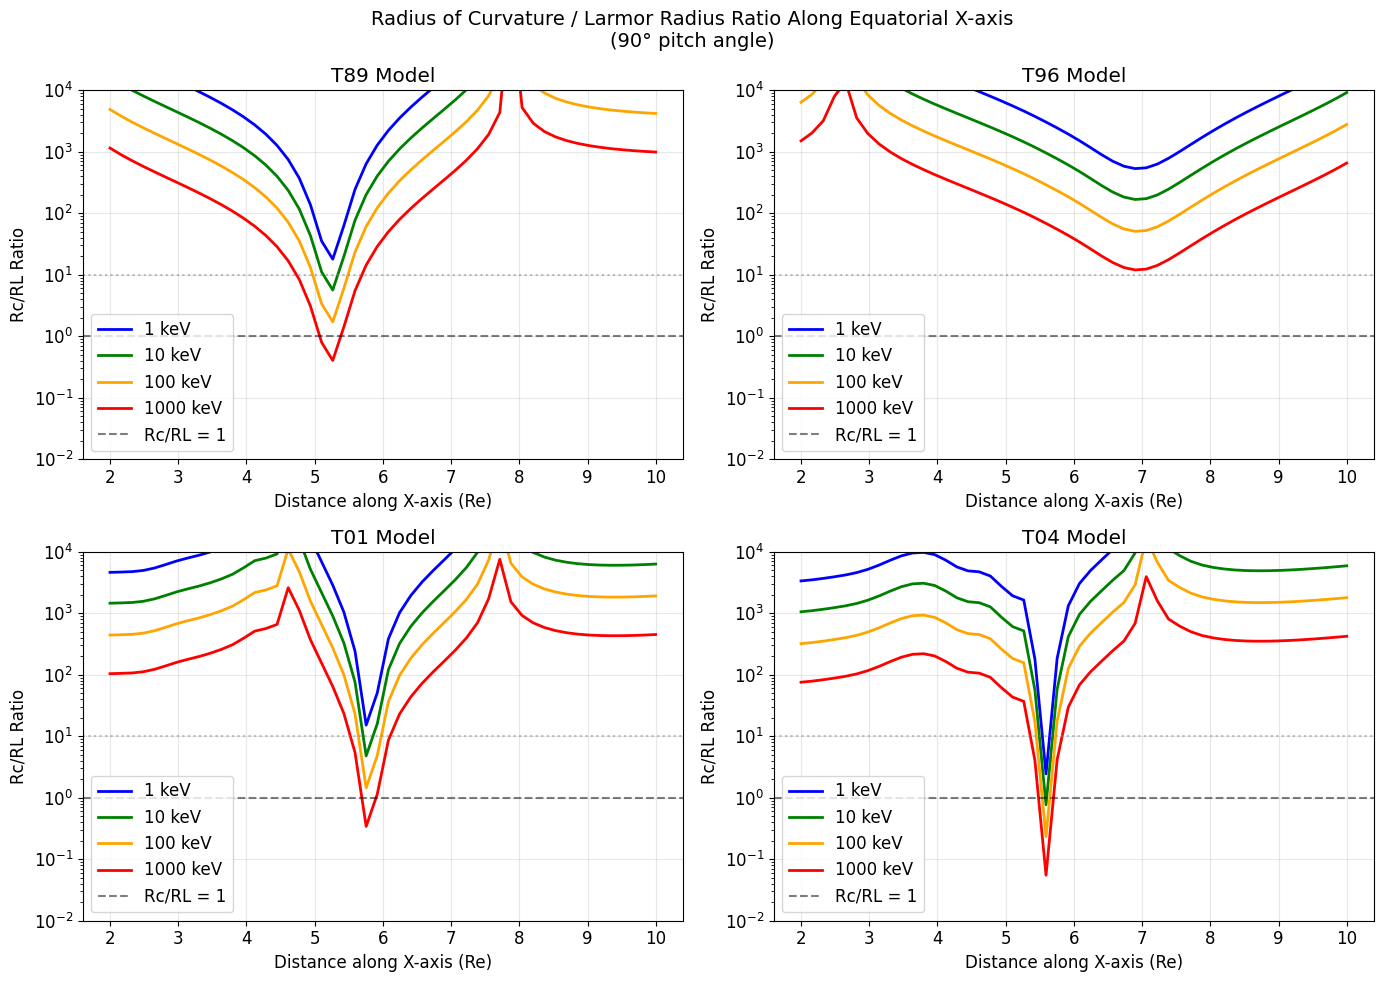


Sample values at X = 6 Re:

T89: Rc = 3.86 Re, B = 5.6 nT
    10 keV: RL =  60.63 km, Rc/RL =   405.2
   100 keV: RL = 199.91 km, Rc/RL =   122.9
  1000 keV: RL = 848.64 km, Rc/RL =    28.9

T96: Rc = 1.48 Re, B = 22.0 nT
    10 keV: RL =  15.43 km, Rc/RL =   611.1
   100 keV: RL =  50.87 km, Rc/RL =   185.3
  1000 keV: RL = 215.96 km, Rc/RL =    43.7

T01: Rc = 0.34 Re, B = 2.5 nT
    10 keV: RL = 135.54 km, Rc/RL =    16.1
   100 keV: RL = 446.92 km, Rc/RL =     4.9
  1000 keV: RL = 1897.24 km, Rc/RL =     1.1

T04: Rc = 5.37 Re, B = 4.1 nT
    10 keV: RL =  82.04 km, Rc/RL =   417.0
   100 keV: RL = 270.52 km, Rc/RL =   126.5
  1000 keV: RL = 1148.42 km, Rc/RL =    29.8


In [4]:
# Energy range for electrons
energies_keV = np.array([1, 10, 100, 1000])  # 1 keV to 1 MeV
colors = ['blue', 'green', 'orange', 'red']

# Points along radial direction (equatorial plane)
r = np.linspace(2, 10, 50)
x_line = r
y_line = np.zeros_like(r)
z_line = np.zeros_like(r)

# Models to compare
models = [
    ('T89', t89_vectorized, kp),
    ('T96', t96_vectorized, parmod_t96),
    ('T01', t01_vectorized, parmod_t01),
    ('T04', t04_vectorized, parmod_t04)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, model_func, params) in enumerate(models):
    ax = axes[idx]
    
    # Calculate curvature radius and B field
    Rc_Re, B_nT = calculate_curvature_radius(model_func, params, ps, x_line, y_line, z_line)
    Rc_m = Rc_Re * Re  # Convert to meters
    
    # Plot for each energy
    for i, (E_keV, color) in enumerate(zip(energies_keV, colors)):
        RL_m = calculate_larmor_radius(E_keV, B_nT, pitch_angle_deg=90)
        ratio = Rc_m / RL_m
        
        ax.semilogy(r, ratio, color=color, linewidth=2, 
                    label=f'{E_keV} keV')
    
    # Add reference lines
    ax.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Rc/RL = 1')
    ax.axhline(y=10, color='gray', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Distance along X-axis (Re)')
    ax.set_ylabel('Rc/RL Ratio')
    ax.set_title(f'{model_name} Model')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    ax.set_ylim(1e-2, 1e4)

plt.suptitle('Radius of Curvature / Larmor Radius Ratio Along Equatorial X-axis\n(90° pitch angle)', 
             fontsize=14)
plt.tight_layout()
plt.show()

# Print some specific values
print("\nSample values at X = 6 Re:")
idx_6Re = np.argmin(np.abs(r - 6.0))
for model_name, model_func, params in models:
    Rc_Re, B_nT = calculate_curvature_radius(model_func, params, ps, x_line[idx_6Re], 
                                             y_line[idx_6Re], z_line[idx_6Re])
    print(f"\n{model_name}: Rc = {Rc_Re:.2f} Re, B = {B_nT:.1f} nT")
    for E_keV in [10, 100, 1000]:
        RL_m = calculate_larmor_radius(E_keV, B_nT)
        ratio = Rc_Re * Re / RL_m
        print(f"  {E_keV:4d} keV: RL = {RL_m/1000:6.2f} km, Rc/RL = {ratio:7.1f}")

## Analysis 2: 2D Maps in Noon-Midnight Meridian

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

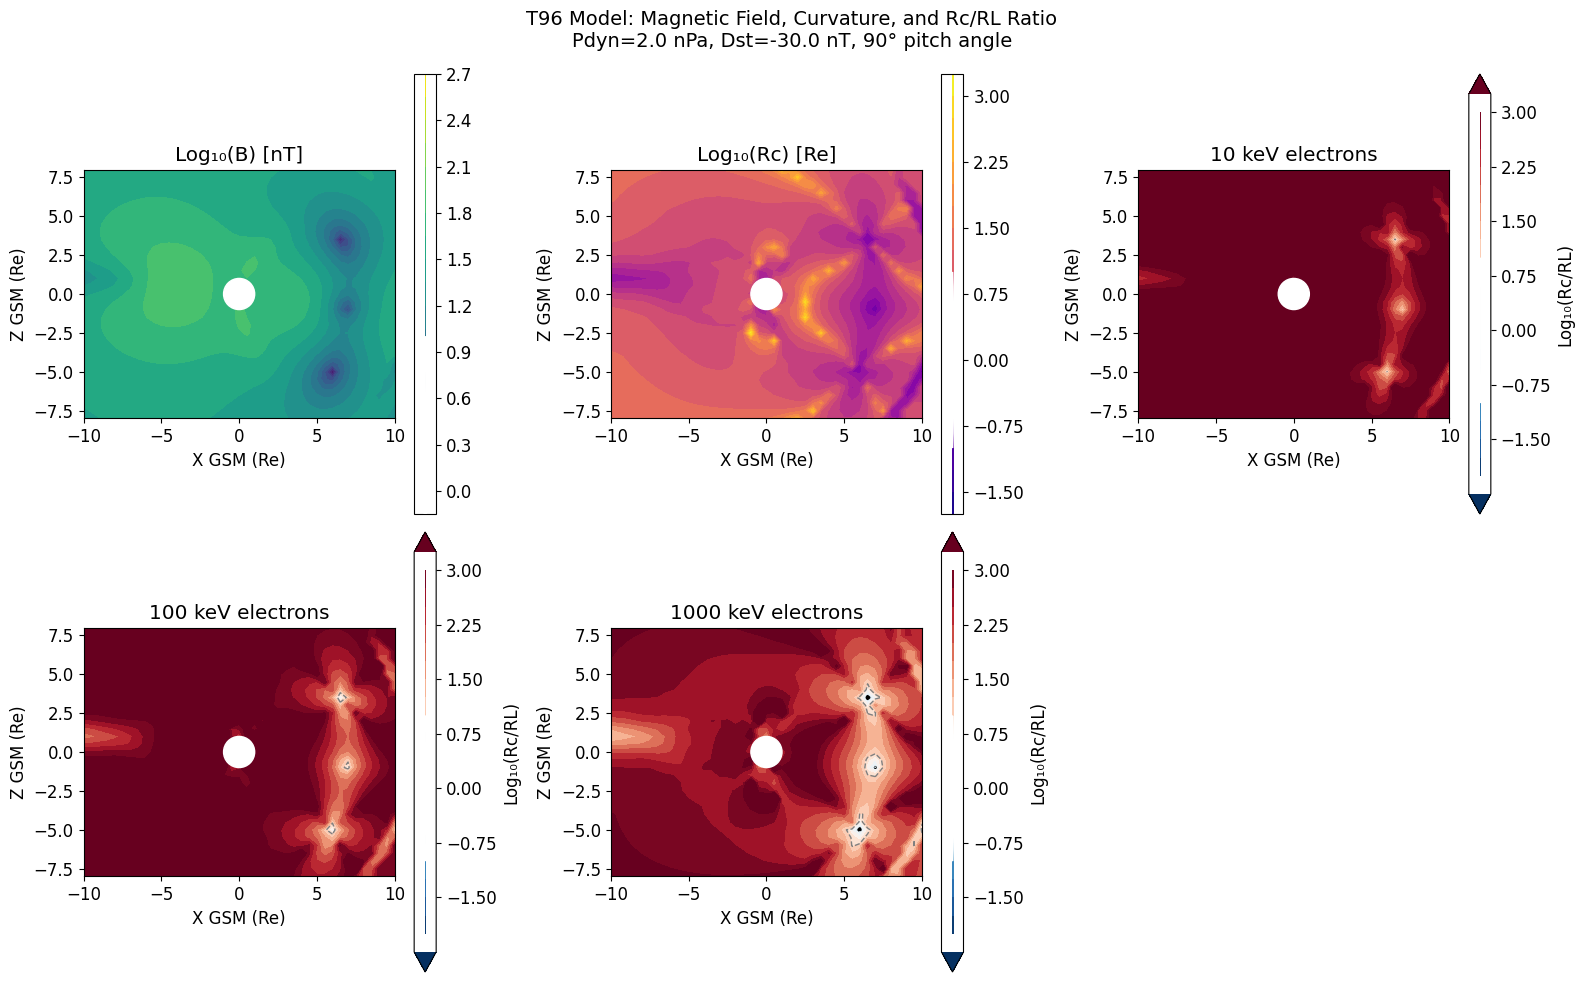


Non-adiabatic regions (Rc/RL < 10) for 100 keV electrons:
Fraction of grid points with Rc/RL < 10: 0.3%


In [5]:
# Create 2D grid
x_grid = np.linspace(-10, 10, 41)
z_grid = np.linspace(-8, 8, 33)
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.zeros_like(X)

# Flatten for calculation
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()

# Calculate for T96 model
Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_t96, ps, 
                                         x_flat, y_flat, z_flat)
Rc_m = Rc_Re * Re

# Reshape
B_grid = B_nT.reshape(X.shape)
Rc_grid = Rc_Re.reshape(X.shape)

# Calculate Rc/RL ratio for different energies
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# First show B field and curvature
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.contourf(X, Z, np.log10(B_grid), levels=20, cmap='viridis')
ax1.set_title('Log₁₀(B) [nT]')
ax1.set_xlabel('X GSM (Re)')
ax1.set_ylabel('Z GSM (Re)')
plt.colorbar(im1, ax=ax1)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.contourf(X, Z, np.log10(Rc_grid), levels=20, cmap='plasma')
ax2.set_title('Log₁₀(Rc) [Re]')
ax2.set_xlabel('X GSM (Re)')
ax2.set_ylabel('Z GSM (Re)')
plt.colorbar(im2, ax=ax2)

# Plot Rc/RL ratio for different energies
energies_plot = [10, 100, 1000]  # keV
positions = [(0, 2), (1, 0), (1, 1), (1, 2)]

for i, E_keV in enumerate(energies_plot):
    ax = fig.add_subplot(gs[positions[i]])
    
    RL_m = calculate_larmor_radius(E_keV, B_nT, pitch_angle_deg=90)
    ratio = Rc_m / RL_m
    ratio_grid = ratio.reshape(X.shape)
    
    # Use log scale for ratio
    im = ax.contourf(X, Z, np.log10(ratio_grid), 
                     levels=np.linspace(-2, 3, 21),
                     cmap='RdBu_r', extend='both')
    
    # Add contour lines for ratio = 1 and 10
    cs1 = ax.contour(X, Z, ratio_grid, levels=[1], colors='black', linewidths=2)
    cs2 = ax.contour(X, Z, ratio_grid, levels=[10], colors='gray', 
                     linewidths=1, linestyles='--')
    
    ax.clabel(cs1, inline=True, fontsize=10, fmt='Rc/RL=1')
    
    ax.set_title(f'{E_keV} keV electrons')
    ax.set_xlabel('X GSM (Re)')
    ax.set_ylabel('Z GSM (Re)')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Log₁₀(Rc/RL)')

# Add Earth to all plots
for ax in fig.axes:
    if hasattr(ax, 'add_patch'):
        earth = plt.Circle((0, 0), 1, color='white', zorder=10)
        ax.add_patch(earth)
        ax.set_aspect('equal')
        ax.set_xlim(-10, 10)
        ax.set_ylim(-8, 8)

plt.suptitle('T96 Model: Magnetic Field, Curvature, and Rc/RL Ratio\n' +
             f'Pdyn={parmod_t96[0]} nPa, Dst={parmod_t96[1]} nT, 90° pitch angle',
             fontsize=14)
plt.tight_layout()
plt.show()

# Identify non-adiabatic regions
print("\nNon-adiabatic regions (Rc/RL < 10) for 100 keV electrons:")
RL_100keV = calculate_larmor_radius(100, B_nT, pitch_angle_deg=90)
ratio_100keV = Rc_m / RL_100keV
non_adiabatic = ratio_100keV < 10
print(f"Fraction of grid points with Rc/RL < 10: {np.sum(non_adiabatic)/len(ratio_100keV)*100:.1f}%")

# Create summary figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Energy threshold for different regions
r_test = np.array([3, 4, 5, 6, 7, 8, 9, 10])
x_test = r_test
y_test = np.zeros_like(r_test)
z_test = np.zeros_like(r_test)

# Calculate threshold energies for Rc/RL = 10
E_threshold = np.zeros(len(r_test), dtype=float)  # Explicitly use float type
E_range_fine = np.logspace(0, 4, 1000)  # 1 keV to 10 MeV

for i, (x, y, z) in enumerate(zip(x_test, y_test, z_test)):
    Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_t96, ps, x, y, z)
    Rc_m = Rc_Re * Re
    
    RL_m = calculate_larmor_radius(E_range_fine, B_nT, pitch_angle_deg=90)
    ratio = Rc_m / RL_m
    
    idx = np.where(ratio < 10)[0]
    if len(idx) > 0:
        E_threshold[i] = E_range_fine[idx[0]]
    else:
        E_threshold[i] = np.nan

# Only plot non-NaN values
mask = ~np.isnan(E_threshold)
ax1.semilogy(r_test[mask], E_threshold[mask], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Distance (Re)')
ax1.set_ylabel('Threshold Energy (keV)')
ax1.set_title('Energy Threshold for Non-Adiabatic Motion\n(Rc/RL < 10, 90° pitch angle)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(10, 1e4)

# Add shaded regions
ax1.axhspan(1, 10, alpha=0.2, color='blue', label='Thermal electrons')
ax1.axhspan(10, 100, alpha=0.2, color='green', label='Ring current')
ax1.axhspan(100, 1000, alpha=0.2, color='orange', label='Radiation belt')
ax1.axhspan(1000, 1e4, alpha=0.2, color='red', label='Relativistic')
ax1.legend(loc='upper left')

# Right: Summary diagram
ax2.text(0.5, 0.9, 'Key Findings:', ha='center', fontsize=14, weight='bold',
         transform=ax2.transAxes)

findings = [
    '1. Inner magnetosphere (r < 4 Re):',
    '   • Strong B field → small Larmor radius',
    '   • Most electrons remain adiabatic',
    '   • Only >MeV electrons become non-adiabatic',
    '',
    '2. Ring current region (4-7 Re):',
    '   • Moderate field curvature',
    '   • 100 keV - 1 MeV electrons marginal',
    '   • Important for radiation belt dynamics',
    '',
    '3. Tail region (r > 8 Re):',
    '   • Weak B field → large Larmor radius',
    '   • Even 10-100 keV electrons non-adiabatic',
    '   • Current sheet scattering region',
    '',
    '4. Storm-time effects:',
    '   • Compression increases B → smaller RL',
    '   • But also increases field complexity',
    '   • Non-adiabatic regions expand'
]

y_pos = 0.75
for line in findings:
    if line.startswith('   '):
        ax2.text(0.1, y_pos, line, transform=ax2.transAxes, fontsize=10)
    elif line and line[0].isdigit():
        ax2.text(0.05, y_pos, line, transform=ax2.transAxes, fontsize=11, weight='bold')
    y_pos -= 0.04

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\nPhysical Implications:")
print("=" * 50)
print("• Rc/RL >> 1: Particles follow guiding center motion")
print("• Rc/RL ~ 1-10: First adiabatic invariant may be violated")
print("• Rc/RL < 1: Chaotic motion, pitch angle scattering")
print("\nThis affects:")
print("- Radiation belt dynamics")
print("- Particle precipitation")
print("- Wave-particle interactions")
print("- Current sheet stability")

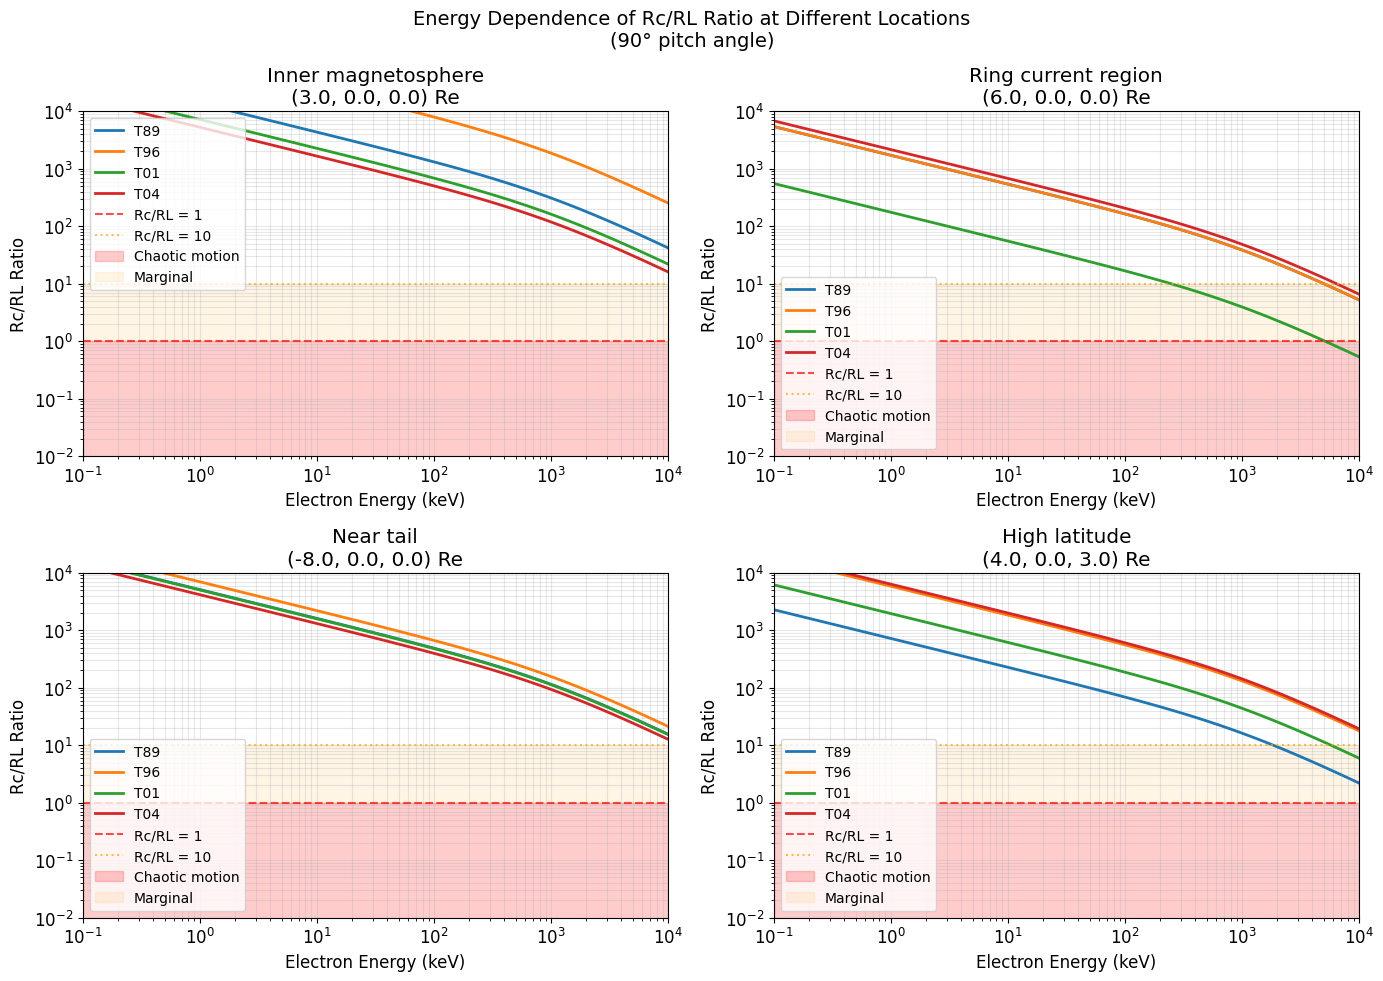


Critical energies where Rc/RL = 10 (keV):
------------------------------------------------------------
Location                    T89        T96        T01        T04
------------------------------------------------------------
Inner magnetosphere         nan        nan        nan        nan
Ring current region      5590.8     5590.8      271.9     7054.8
Near tail                   nan        nan        nan        nan
High latitude            1963.0        nan     6280.3        nan


In [6]:
# Define specific locations of interest
locations = [
    ("Inner magnetosphere", 3.0, 0.0, 0.0),
    ("Ring current region", 6.0, 0.0, 0.0),
    ("Near tail", -8.0, 0.0, 0.0),
    ("High latitude", 4.0, 0.0, 3.0)
]

# Energy range
E_range = np.logspace(-1, 4, 100)  # 0.1 keV to 10 MeV

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (loc_name, x, y, z) in enumerate(locations):
    ax = axes[idx]
    
    # Calculate for each model
    for model_name, model_func, params in models:
        Rc_Re, B_nT = calculate_curvature_radius(model_func, params, ps, x, y, z)
        Rc_m = Rc_Re * Re
        
        # Calculate ratio for all energies
        RL_m = calculate_larmor_radius(E_range, B_nT, pitch_angle_deg=90)
        ratio = Rc_m / RL_m
        
        ax.loglog(E_range, ratio, linewidth=2, label=model_name)
    
    # Add reference lines
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Rc/RL = 1')
    ax.axhline(y=10, color='orange', linestyle=':', alpha=0.7, label='Rc/RL = 10')
    
    # Shade non-adiabatic region
    ax.fill_between(E_range, 0, 1, alpha=0.2, color='red', label='Chaotic motion')
    ax.fill_between(E_range, 1, 10, alpha=0.1, color='orange', label='Marginal')
    
    ax.set_xlabel('Electron Energy (keV)')
    ax.set_ylabel('Rc/RL Ratio')
    ax.set_title(f'{loc_name}\n({x}, {y}, {z}) Re')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlim(0.1, 1e4)
    ax.set_ylim(1e-2, 1e4)

plt.suptitle('Energy Dependence of Rc/RL Ratio at Different Locations\n(90° pitch angle)', 
             fontsize=14)
plt.tight_layout()
plt.show()

# Find critical energies
print("\nCritical energies where Rc/RL = 10 (keV):")
print("-" * 60)
print(f"{'Location':<20} {'T89':>10} {'T96':>10} {'T01':>10} {'T04':>10}")
print("-" * 60)

for loc_name, x, y, z in locations:
    critical_E = []
    for model_name, model_func, params in models:
        Rc_Re, B_nT = calculate_curvature_radius(model_func, params, ps, x, y, z)
        Rc_m = Rc_Re * Re
        
        # Find energy where Rc/RL = 10
        RL_m = calculate_larmor_radius(E_range, B_nT, pitch_angle_deg=90)
        ratio = Rc_m / RL_m
        
        # Find crossing point
        idx = np.where(ratio < 10)[0]
        if len(idx) > 0:
            E_crit = E_range[idx[0]]
        else:
            E_crit = np.nan
        critical_E.append(E_crit)
    
    print(f"{loc_name:<20} {critical_E[0]:>10.1f} {critical_E[1]:>10.1f} "
          f"{critical_E[2]:>10.1f} {critical_E[3]:>10.1f}")

## Analysis 4: Effect of Pitch Angle

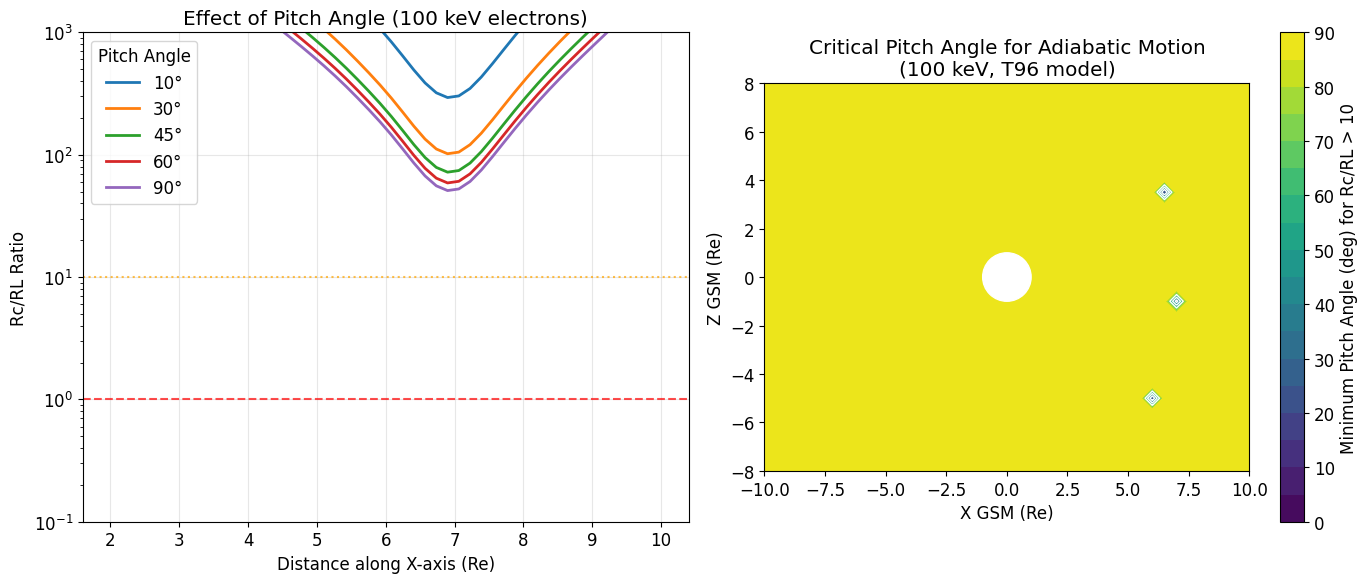


For 100 keV electrons:
Smaller pitch angles → smaller Larmor radius → larger Rc/RL ratio
Field-aligned particles (small pitch angle) remain adiabatic at higher energies


In [7]:
# Analyze pitch angle dependence
pitch_angles = np.array([10, 30, 45, 60, 90])  # degrees
energy_fixed = 100  # keV

# Use T96 model
model_func = t96_vectorized
params = parmod_t96

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Along radial line
for pa in pitch_angles:
    Rc_Re, B_nT = calculate_curvature_radius(model_func, params, ps, x_line, y_line, z_line)
    Rc_m = Rc_Re * Re
    
    RL_m = calculate_larmor_radius(energy_fixed, B_nT, pitch_angle_deg=pa)
    ratio = Rc_m / RL_m
    
    ax1.semilogy(r, ratio, linewidth=2, label=f'{pa}°')

ax1.axhline(y=10, color='orange', linestyle=':', alpha=0.7)
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Distance along X-axis (Re)')
ax1.set_ylabel('Rc/RL Ratio')
ax1.set_title(f'Effect of Pitch Angle ({energy_fixed} keV electrons)')
ax1.grid(True, alpha=0.3)
ax1.legend(title='Pitch Angle', loc='best')
ax1.set_ylim(1e-1, 1e3)

# Right plot: 2D map of critical pitch angle
# Find pitch angle where Rc/RL = 10
pa_range = np.linspace(1, 90, 90)
critical_pa = np.zeros_like(x_flat)

Rc_Re, B_nT = calculate_curvature_radius(model_func, params, ps, x_flat, y_flat, z_flat)
Rc_m = Rc_Re * Re

for i in range(len(x_flat)):
    if Rc_Re[i] > 1e9:  # Skip regions with no curvature
        critical_pa[i] = np.nan
        continue
        
    # Find critical pitch angle
    RL_m_pa = calculate_larmor_radius(energy_fixed, B_nT[i], pitch_angle_deg=pa_range)
    ratio_pa = Rc_m[i] / RL_m_pa
    
    idx = np.where(ratio_pa > 10)[0]
    if len(idx) > 0:
        critical_pa[i] = pa_range[idx[-1]]
    else:
        critical_pa[i] = 0  # Always non-adiabatic

critical_pa_grid = critical_pa.reshape(X.shape)

im = ax2.contourf(X, Z, critical_pa_grid, levels=np.linspace(0, 90, 19), cmap='viridis')
cs = ax2.contour(X, Z, critical_pa_grid, levels=[30, 45, 60], colors='white', linewidths=1)
ax2.clabel(cs, inline=True, fontsize=10)

ax2.set_title(f'Critical Pitch Angle for Adiabatic Motion\n({energy_fixed} keV, T96 model)')
ax2.set_xlabel('X GSM (Re)')
ax2.set_ylabel('Z GSM (Re)')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Minimum Pitch Angle (deg) for Rc/RL > 10')

# Add Earth
earth = plt.Circle((0, 0), 1, color='white', zorder=10)
ax2.add_patch(earth)
ax2.set_aspect('equal')
ax2.set_xlim(-10, 10)
ax2.set_ylim(-8, 8)

plt.tight_layout()
plt.show()

print(f"\nFor {energy_fixed} keV electrons:")
print("Smaller pitch angles → smaller Larmor radius → larger Rc/RL ratio")
print("Field-aligned particles (small pitch angle) remain adiabatic at higher energies")

## Analysis 5: Storm-Time Effects


Quiet:
  Non-adiabatic (Rc/RL < 10): 1.0%
  Chaotic (Rc/RL < 1): 0.1%

Moderate:
  Non-adiabatic (Rc/RL < 10): 0.6%
  Chaotic (Rc/RL < 1): 0.0%

Storm:
  Non-adiabatic (Rc/RL < 10): 0.1%
  Chaotic (Rc/RL < 1): 0.0%


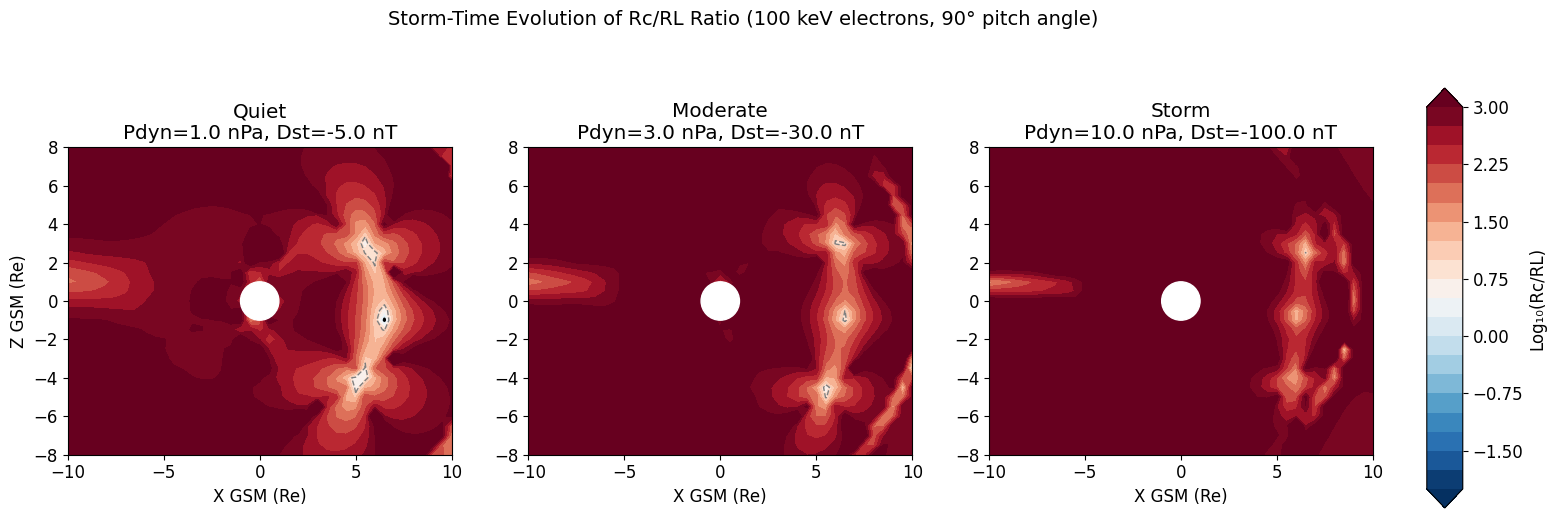

In [8]:
# Compare quiet vs storm conditions
conditions = [
    ("Quiet", [1.0, -5.0, 0.0, 2.0]),      # Quiet conditions
    ("Moderate", [3.0, -30.0, 1.0, -3.0]), # Moderate storm
    ("Storm", [10.0, -100.0, 5.0, -10.0])  # Major storm
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
energy_test = 100  # keV

vmin = -2
vmax = 3

for idx, (condition, params) in enumerate(conditions):
    ax = axes[idx]
    
    # Add unused parameters for T96
    full_params = params + [0, 0, 0, 0, 0, 0]
    
    # Calculate fields
    Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, full_params, ps, 
                                             x_flat, y_flat, z_flat)
    Rc_m = Rc_Re * Re
    
    # Calculate ratio
    RL_m = calculate_larmor_radius(energy_test, B_nT, pitch_angle_deg=90)
    ratio = Rc_m / RL_m
    ratio_grid = ratio.reshape(X.shape)
    
    # Plot
    im = ax.contourf(X, Z, np.log10(ratio_grid), 
                     levels=np.linspace(vmin, vmax, 21),
                     cmap='RdBu_r', extend='both')
    
    # Add contours
    cs1 = ax.contour(X, Z, ratio_grid, levels=[1], colors='black', linewidths=2)
    cs2 = ax.contour(X, Z, ratio_grid, levels=[10], colors='gray', 
                     linewidths=1, linestyles='--')
    
    ax.set_title(f'{condition}\nPdyn={params[0]} nPa, Dst={params[1]} nT')
    ax.set_xlabel('X GSM (Re)')
    if idx == 0:
        ax.set_ylabel('Z GSM (Re)')
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(earth)
    ax.set_aspect('equal')
    ax.set_xlim(-10, 10)
    ax.set_ylim(-8, 8)
    
    # Calculate statistics
    non_adiabatic = ratio < 10
    chaotic = ratio < 1
    print(f"\n{condition}:")
    print(f"  Non-adiabatic (Rc/RL < 10): {np.sum(non_adiabatic)/len(ratio)*100:.1f}%")
    print(f"  Chaotic (Rc/RL < 1): {np.sum(chaotic)/len(ratio)*100:.1f}%")

# Add colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Log₁₀(Rc/RL)')

plt.suptitle(f'Storm-Time Evolution of Rc/RL Ratio ({energy_test} keV electrons, 90° pitch angle)', 
             fontsize=14)
plt.show()

## Summary and Physical Interpretation

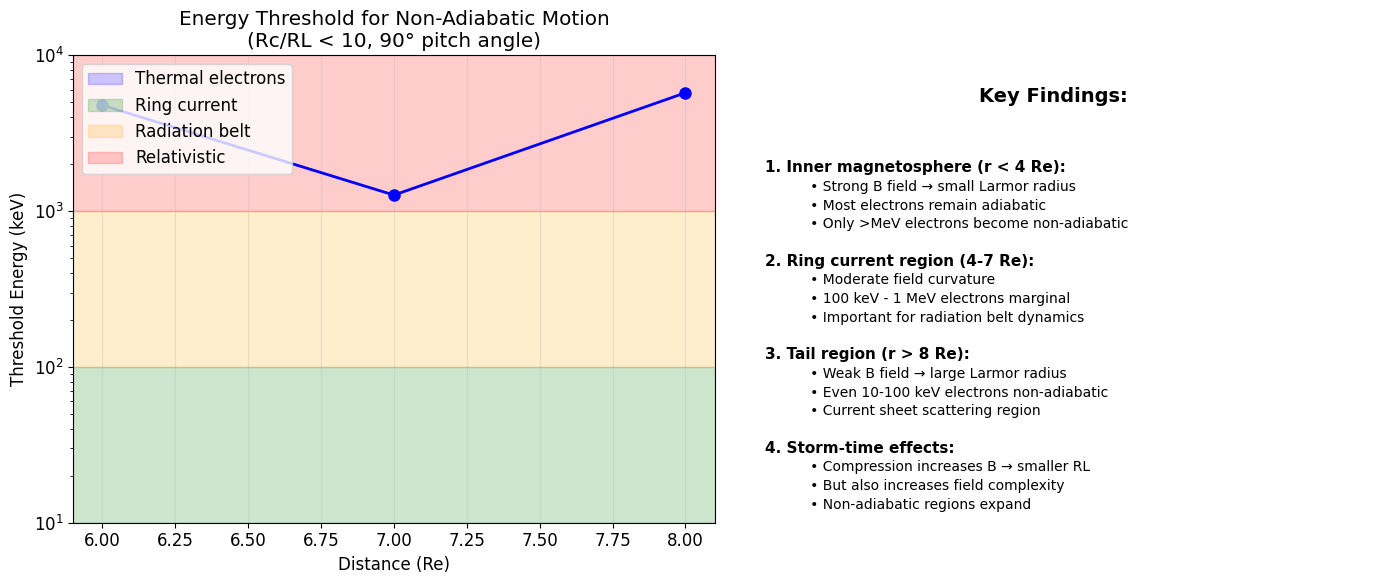


Physical Implications:
• Rc/RL >> 1: Particles follow guiding center motion
• Rc/RL ~ 1-10: First adiabatic invariant may be violated
• Rc/RL < 1: Chaotic motion, pitch angle scattering

This affects:
- Radiation belt dynamics
- Particle precipitation
- Wave-particle interactions
- Current sheet stability


In [9]:
# Create summary figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Energy threshold for different regions
r_test = np.array([3, 4, 5, 6, 7, 8, 9, 10])
x_test = r_test
y_test = np.zeros_like(r_test)
z_test = np.zeros_like(r_test)

# Calculate threshold energies for Rc/RL = 10
E_threshold = np.zeros(len(r_test), dtype=float)  # Explicitly use float type
E_range_fine = np.logspace(0, 4, 1000)  # 1 keV to 10 MeV

for i, (x, y, z) in enumerate(zip(x_test, y_test, z_test)):
    Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_t96, ps, x, y, z)
    Rc_m = Rc_Re * Re
    
    RL_m = calculate_larmor_radius(E_range_fine, B_nT, pitch_angle_deg=90)
    ratio = Rc_m / RL_m
    
    idx = np.where(ratio < 10)[0]
    if len(idx) > 0:
        E_threshold[i] = E_range_fine[idx[0]]
    else:
        E_threshold[i] = np.nan

# Only plot non-NaN values
mask = ~np.isnan(E_threshold)
ax1.semilogy(r_test[mask], E_threshold[mask], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Distance (Re)')
ax1.set_ylabel('Threshold Energy (keV)')
ax1.set_title('Energy Threshold for Non-Adiabatic Motion\n(Rc/RL < 10, 90° pitch angle)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(10, 1e4)

# Add shaded regions
ax1.axhspan(1, 10, alpha=0.2, color='blue', label='Thermal electrons')
ax1.axhspan(10, 100, alpha=0.2, color='green', label='Ring current')
ax1.axhspan(100, 1000, alpha=0.2, color='orange', label='Radiation belt')
ax1.axhspan(1000, 1e4, alpha=0.2, color='red', label='Relativistic')
ax1.legend(loc='upper left')

# Right: Summary diagram
ax2.text(0.5, 0.9, 'Key Findings:', ha='center', fontsize=14, weight='bold',
         transform=ax2.transAxes)

findings = [
    '1. Inner magnetosphere (r < 4 Re):',
    '   • Strong B field → small Larmor radius',
    '   • Most electrons remain adiabatic',
    '   • Only >MeV electrons become non-adiabatic',
    '',
    '2. Ring current region (4-7 Re):',
    '   • Moderate field curvature',
    '   • 100 keV - 1 MeV electrons marginal',
    '   • Important for radiation belt dynamics',
    '',
    '3. Tail region (r > 8 Re):',
    '   • Weak B field → large Larmor radius',
    '   • Even 10-100 keV electrons non-adiabatic',
    '   • Current sheet scattering region',
    '',
    '4. Storm-time effects:',
    '   • Compression increases B → smaller RL',
    '   • But also increases field complexity',
    '   • Non-adiabatic regions expand'
]

y_pos = 0.75
for line in findings:
    if line.startswith('   '):
        ax2.text(0.1, y_pos, line, transform=ax2.transAxes, fontsize=10)
    elif line and line[0].isdigit():
        ax2.text(0.05, y_pos, line, transform=ax2.transAxes, fontsize=11, weight='bold')
    y_pos -= 0.04

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\nPhysical Implications:")
print("=" * 50)
print("• Rc/RL >> 1: Particles follow guiding center motion")
print("• Rc/RL ~ 1-10: First adiabatic invariant may be violated")
print("• Rc/RL < 1: Chaotic motion, pitch angle scattering")
print("\nThis affects:")
print("- Radiation belt dynamics")
print("- Particle precipitation")
print("- Wave-particle interactions")
print("- Current sheet stability")